<a href="https://colab.research.google.com/github/negarmajma/Customer_churn_prediction_with_dif_Algorithm_and_GeneticAlgo_Selection/blob/main/Stock_Market_Index_Forecasting_in_Iraq_Using_RNN_Optimized_by_Horse_Herd_Optimization_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization

In [3]:
# Minimal HHO Algorithm
def HHO(objective_function, bounds, n_agents=3, n_iter=3, seed=42):
    np.random.seed(seed)
    dim = len(bounds)
    X = np.zeros((n_agents, dim))
    for i in range(dim):
        X[:, i] = np.random.uniform(bounds[i][0], bounds[i][1], n_agents)
    fitness = np.array([objective_function(x) for x in X])
    best_idx = np.argmin(fitness)
    X_best = X[best_idx].copy()
    best_fitness = fitness[best_idx]

    for t in range(n_iter):
        E1 = 2 * (1 - (t / n_iter))
        for i in range(n_agents):
            E0 = 2 * np.random.rand() - 1
            E = E1 * E0
            if abs(E) >= 1:
                rand_agent = X[np.random.randint(n_agents)]
                X[i] = rand_agent - np.random.rand() * abs(rand_agent - 2 * np.random.rand() * X[i])
            else:
                X[i] = X_best - abs(X_best - X[i]) * E
            for d in range(dim):
                X[i, d] = np.clip(X[i, d], bounds[d][0], bounds[d][1])
        fitness = np.array([objective_function(x) for x in X])
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_fitness:
            X_best = X[best_idx].copy()
            best_fitness = fitness[best_idx]
    return X_best, best_fitness


In [4]:
# Parameter bounds
bounds = [
    (16, 64),      # n_units
    (0.001, 0.01), # learning_rate
    (16, 64)       # batch_size
]

In [5]:
seq_length = 10
random_state = 42

file_path = 'banks_data.xlsx'
xls = pd.ExcelFile(file_path)
bank_sheets = xls.sheet_names
results = []

In [8]:
for bank_symbol in bank_sheets:
    df = pd.read_excel(file_path, sheet_name=bank_symbol)
    df = df.fillna(method='ffill').fillna(method='bfill')
    columns_to_scale = ['قیمت باز', 'کمترین قیمت', 'بیشترین قیمت', 'قیمت بسته', 'حجم', 'قیمت بسته تعدیل‌شده']
    scaler = MinMaxScaler()
    df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
    total_len = len(df)
    if total_len < seq_length + 40:
        print(f"{bank_symbol} داده کافی ندارد.")
        continue

    train_size = int(0.6 * total_len)
    val_size = int(0.2 * total_len)
    test_size = total_len - train_size - val_size
    train_df = df.iloc[:train_size]
    val_df = df.iloc[train_size:train_size+val_size]
    test_df = df.iloc[train_size+val_size:]

    def create_sequences(data, seq_length):
        xs, ys = [], []
        data = data.reset_index(drop=True)
        for i in range(len(data) - seq_length):
            x = data.loc[i:i+seq_length-1, columns_to_scale].values
            y = 1 if data.loc[i+seq_length, 'قیمت بسته'] > data.loc[i+seq_length-1, 'قیمت بسته'] else 0
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(train_df, seq_length)
    X_val, y_val = create_sequences(val_df, seq_length)
    X_test, y_test = create_sequences(test_df, seq_length)
    if X_train.shape[0] < 20 or X_val.shape[0] < 10 or X_test.shape[0] < 10:
        print(f"{bank_symbol} داده کافی برای آموزش/اعتبارسنجی ندارد.")
        continue

    def objective(params):
        n_units = int(round(params[0]))
        learning_rate = float(params[1])
        batch_size = int(round(params[2]))
        model = Sequential([
            SimpleRNN(n_units, activation='tanh', input_shape=(seq_length, len(columns_to_scale))),
            BatchNormalization(),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])
        model.compile(
            loss='binary_crossentropy',
            optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
            metrics=['accuracy']
        )
        model.fit(X_train, y_train, epochs=5, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)
        val_pred = model.predict(X_val)
        val_pred = (val_pred > 0.5).astype(int).flatten()
        acc = accuracy_score(y_val, val_pred)
        return 1 - acc

    print(f"بهینه‌سازی پارامترها با HHO برای {bank_symbol} ...")
    best_params, _ = HHO(objective, bounds, n_agents=3, n_iter=3)
    n_units = int(round(best_params[0]))
    learning_rate = float(best_params[1])
    batch_size = int(round(best_params[2]))

    model = Sequential([
        SimpleRNN(n_units, activation='tanh', input_shape=(seq_length, len(columns_to_scale))),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    model.fit(X_train, y_train, epochs=10, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    acc = (precision + recall) / 2

    results.append({
        "بانک": bank_symbol,
        "accuracy": round(precision, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3),
        "Accuracy": round(acc, 3),
        "تعداد نمونه تست": len(y_test),
        "n_units": n_units,
        "lr": learning_rate,
        "batch_size": batch_size
     })

/tmp/ipython-input-528004916.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


بهینه‌سازی پارامترها با HHO برای BASH ...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [9]:
results_df = pd.DataFrame(results)
print(results_df)

   بانک  accuracy  Precision  Recall     F1  Accuracy  تعداد نمونه تست  \
0  BASH     0.640      0.640   0.898  0.748     0.769              257   
1  BBAY     0.561      0.561   0.988  0.716     0.775              349   
2  BBOB     0.000      0.000   0.000  0.000     0.000              190   
3  BCOI     0.756      0.756   0.660  0.705     0.708              190   
4  BDFD     0.714      0.714   0.682  0.698     0.698               87   
5  BEFI     0.838      0.838   0.596  0.697     0.717              104   
6  BELF     0.667      0.667   0.714  0.690     0.690               91   
7  BGUC     0.765      0.765   0.667  0.713     0.716              190   
8  BIBI     0.726      0.726   0.819  0.770     0.773              190   

   n_units        lr  batch_size  
0       34  0.006388          19  
1       34  0.006388          19  
2       62  0.002404          58  
3       39  0.001000          25  
4       64  0.002654          64  
5       64  0.003182          61  
6       34  0.

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7357 - loss: 0.5218 - val_accuracy: 0.7105 - val_loss: 0.5861
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7487 - loss: 0.5140 - val_accuracy: 0.6842 - val_loss: 0.5788
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7360 - loss: 0.5347 - val_accuracy: 0.6947 - val_loss: 0.5733
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7538 - loss: 0.5170 - val_accuracy: 0.7053 - val_loss: 0.5752
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7548 - loss: 0.5170 - val_accuracy: 0.6947 - val_loss: 0.5730
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7465 - loss: 0.5191 - val_accuracy: 0.7000 - val_loss: 0.5656
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7476 - loss: 0.5214 - val_accuracy: 0.6947 - val_loss: 0.5612
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7451 - loss: 0.5377 - val_accuracy: 0.7000 - v

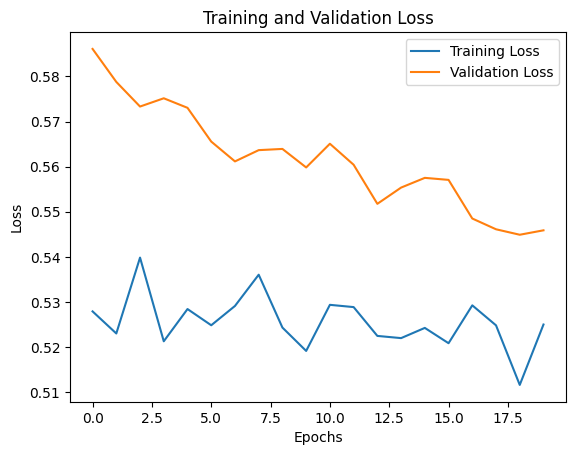

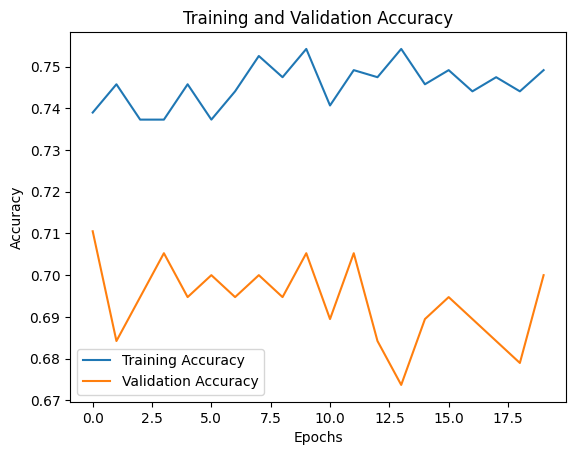

In [10]:
import matplotlib.pyplot as plt

history = model.fit(X_train, y_train, epochs=20, batch_size=64,
                    validation_data=(X_val, y_val), verbose=1)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


In [12]:
from scipy.stats import ttest_rel

# Example: accuracies of two models across multiple runs
acc_HHOA = [0.7105 , 0.6842, 0.6947, 0.7053, 0.6947, 0.7000, 0.6947, 0.7000, 0.6947, 0.7053, 0.6895, 0.7053, 0.6842, 0.6737, 0.6895, 0.6947, 0.6895, 0.6842, 0.6789, 0.7000]
acc_PSO  = [0.731, 0.729, 0.733, 0.728, 0.732,0.728, 0.732,0.731, 0.729,0.732,0.728,0.729,0.733,0.728, 0.732,0.728,0.732,0.728, 0.732,0.731]

t_stat, p_value = ttest_rel(acc_HHOA, acc_PSO)
print("p-value =", p_value)


p-value = 7.190820846512796e-13
